In [ ]:
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

from scipy.stats import chi2_contingency
import numpy as np

In [ ]:
df = pd.read_csv('../datos/income_data.csv')

In [ ]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.sample(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
34908,62,Private,24515,9th,5,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
8832,24,Private,152724,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Black,Male,0,0,40,United-States,<=50K
13892,53,Private,402016,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,52,United-States,>50K
13016,17,Private,364491,11th,7,Never-married,Sales,Own-child,White,Male,0,0,22,United-States,<=50K
40300,17,Private,394176,10th,6,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


analizamos la estructura del dataset para ver como se comportan las variables

sabemos que la variable objetivo es income que nos dice si alguien cobra mas o menos de 50.000 euros 

empezamos a tratar los datos una ves hemos visto la estructura, buscamos nulos y duplicados 

In [ ]:
df.duplicated().sum()

np.int64(52)

al haber solo 52 duplicados que encima pueden ser por que diferentes individuos compartan las mismas caracteristicas creemos que es mejor no eliminarlo. 

In [ ]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

no parece haber ningun nulo pero es porque estan marcados como "?" no como valor nulo 

In [ ]:
(df == '?').sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [ ]:
df = df.replace('?', np.nan)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

occupation         2809
workclass          2799
native-country      857
fnlwgt                0
education             0
educational-num       0
age                   0
marital-status        0
relationship          0
gender                0
race                  0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

dejamos asi marcados los nulos ya que los trataremos en la parte del preprocesing solo los dejamos como nan 

Ahora pasamos a hacer el analisis univariable empezando con la variable objetivo income 

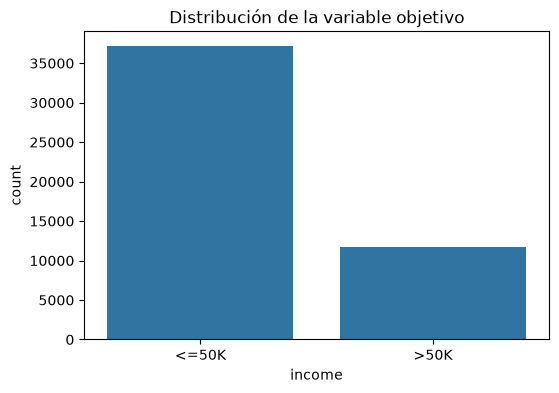

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='income')

plt.title('Distribución de la variable objetivo')
plt.show()

vemos que la variable objetivo esta desbalanceada, hay bastante mas gente que gana menos de 50mil euros de la que hay que ganan mas de 50mil euros 

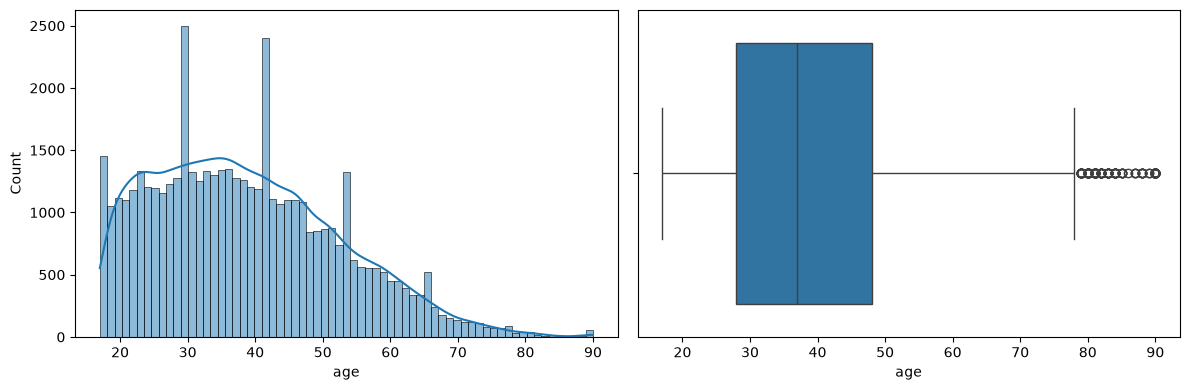

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['age'], kde=True, ax=ax[0])
sns.boxplot(x=df['age'], ax=ax[1])

plt.tight_layout()
plt.show()

La distribución de la edad presenta una ligera asimetría positiva, concentrándose la mayor parte de los individuos entre los 25 y los 50 años aunque se aprecian algunos outliers. 


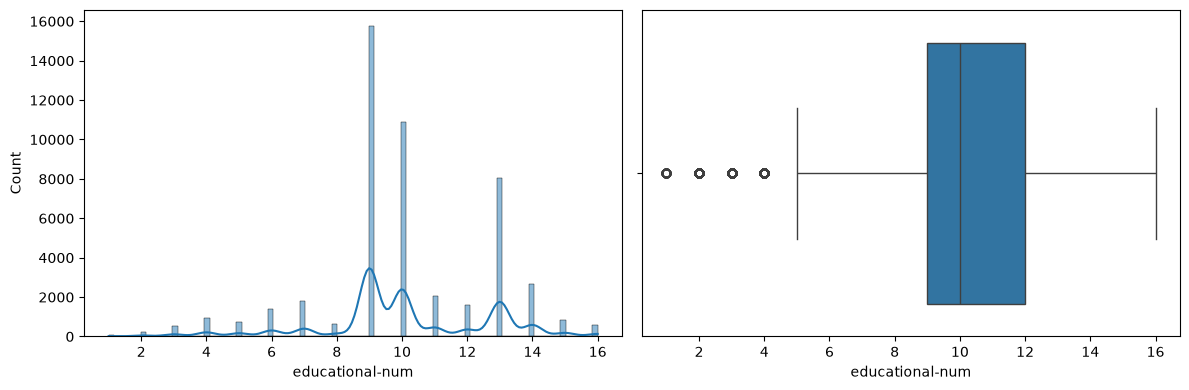

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['educational-num'], kde=True, ax=ax[0])
sns.boxplot(x=df['educational-num'], ax=ax[1])

plt.tight_layout()
plt.show()

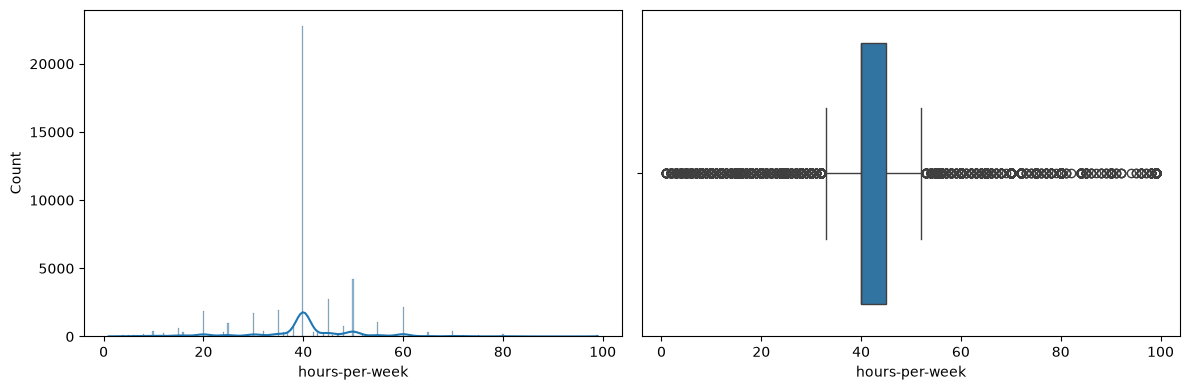

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['hours-per-week'], kde=True, ax=ax[0])
sns.boxplot(x=df['hours-per-week'], ax=ax[1])

plt.tight_layout()
plt.show()

La variable horas trabajadas por semana muestra una elevada concentración alrededor de las 40 horas semanales que tiene sentido porque es una jornada laboral estandar 

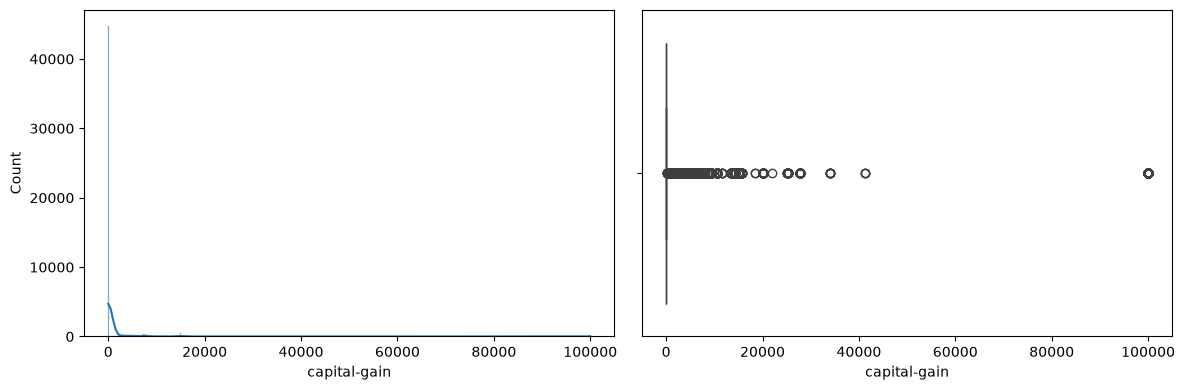

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['capital-gain'], kde=True, ax=ax[0])
sns.boxplot(x=df['capital-gain'], ax=ax[1])

plt.tight_layout()
plt.show()

la gran mayoria de personas no registran ganancias de capital y un pequeño grupo tiene valores muy elevados 


como la gran mayoria de observaciones son 0 se crea una distribucion asimetrica bastante extrema, durante el preprocesing se buscara una manera que permita representar la informacion de manera mas sencilla 

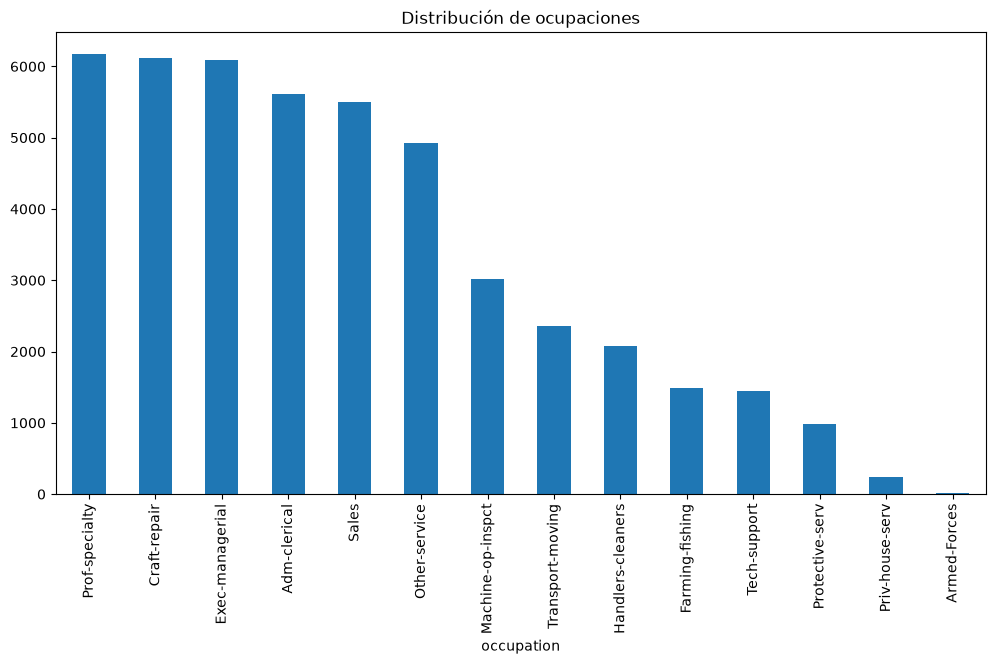

In [ ]:
plt.figure(figsize=(12,6))

df['occupation'].value_counts().plot(kind='bar')

plt.title('Distribución de ocupaciones')
plt.xticks(rotation=90)

plt.show()

La ocupación presenta una distribución bastante variada. Las categorías relacionadas con actividades técnicas, administrativas y de servicios concentran la mayor parte de los casos

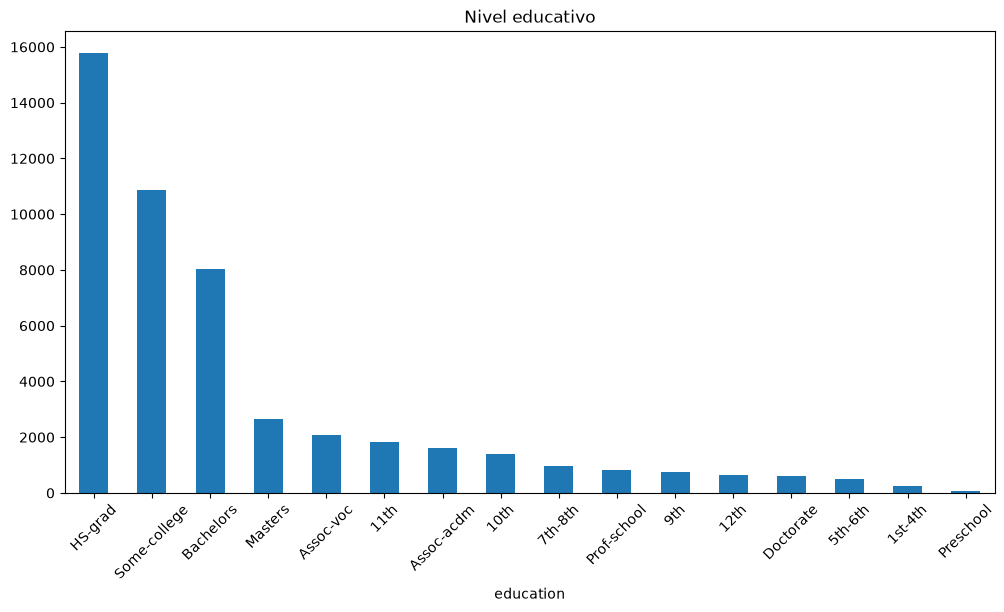

In [ ]:
plt.figure(figsize=(12,6))

df['education'].value_counts().plot(kind='bar')

plt.title('Nivel educativo')
plt.xticks(rotation=45)

plt.show()

Los niveles educativos más frecuentes corresponden a estudios de secundaria y formación superior. La presencia de distintos niveles educativos nos llevara a pensar que aquellas personas con mayor nivel educativo tendran mayores ingresos 

Dado que educational num y education son variables contienen información muy similar, durante la fase de preprocesamiento se estudiará la posibilidad de conservar únicamente una de ellas para evitar redundancia

In [ ]:
df['native-country'].value_counts().head(15)

native-country
United-States         43832
Mexico                  951
Philippines             295
Germany                 206
Puerto-Rico             184
Canada                  182
El-Salvador             155
India                   151
Cuba                    138
England                 127
China                   122
South                   115
Jamaica                 106
Italy                   105
Dominican-Republic      103
Name: count, dtype: int64

dado el gran numero de paises que tenemos se podria agruparlos por continentes en la parte del preprocesing 

Ahora que hemos analizado las variables mas importantes en el analisis univariable pasamos al analisis bivariable comparando la variable objetivo con el resto de variables para ver como se relacionan. 

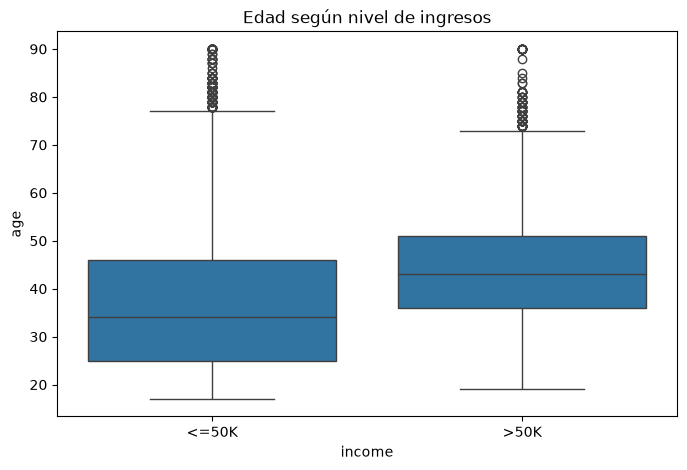

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='age'
)

plt.title('Edad según nivel de ingresos')
plt.show()

Se observa que los individuos con ingresos superiores a 50K presentan, en promedio, edades más elevada, esto es coherente ya que una mayor edad tambien se relaciona con mayor experiencia laboral y mayor desarrollo personal 

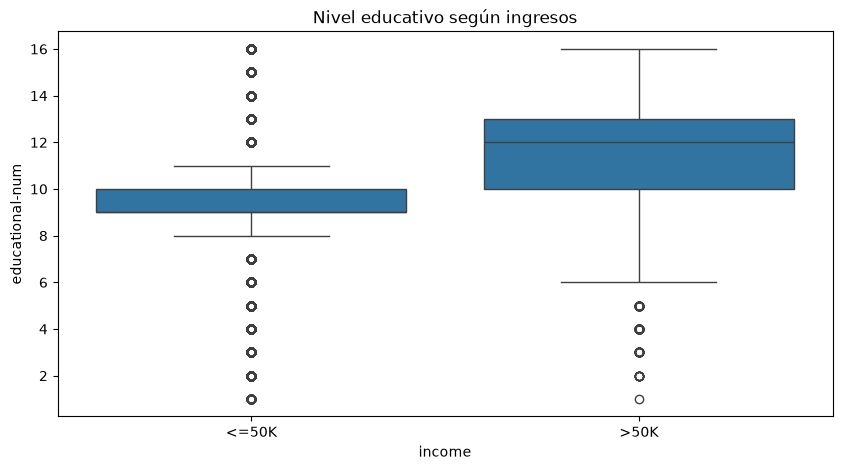

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='income',
    y='educational-num'
)

plt.title('Nivel educativo según ingresos')
plt.show()

In [ ]:
El nivel educativo muestra una relación positiva con los ingresos. Esto tambien es coherente ya que a mayor educacion tambien se relaciona con mayoe entendimiento con la carrera. 

SyntaxError: invalid syntax (2203335689.py, line 1)

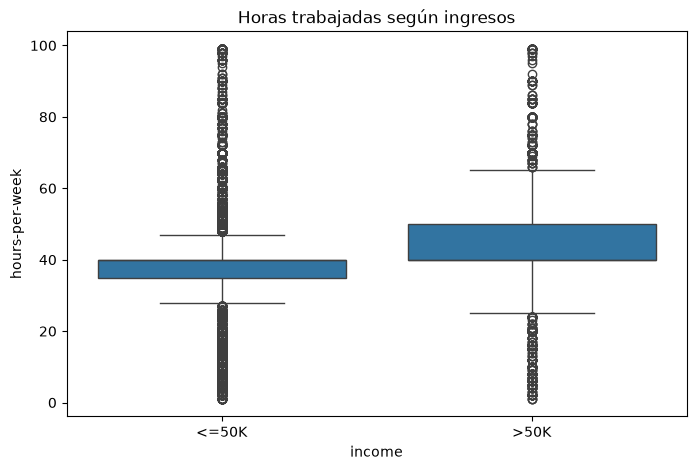

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Horas trabajadas según ingresos')
plt.show()

esta tabla nos enseña que a mayor horas trabajadas tambien tienes mas nivel de ingresos a pesar del gran nivel de outliers que presenta la tabla. 

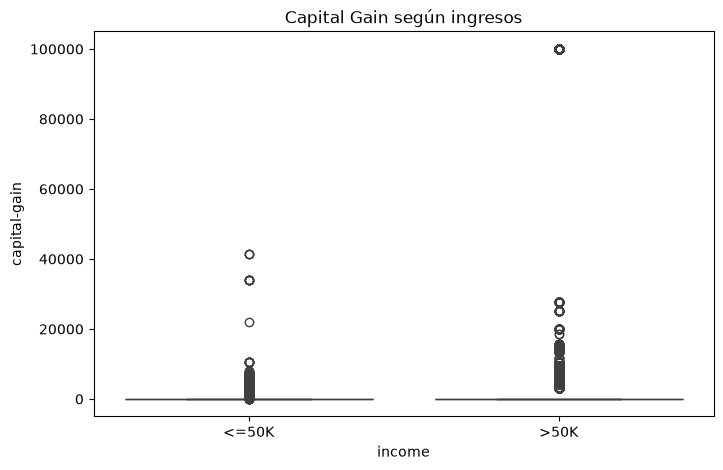

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='capital-gain'
)

plt.title('Capital Gain según ingresos')
plt.show()

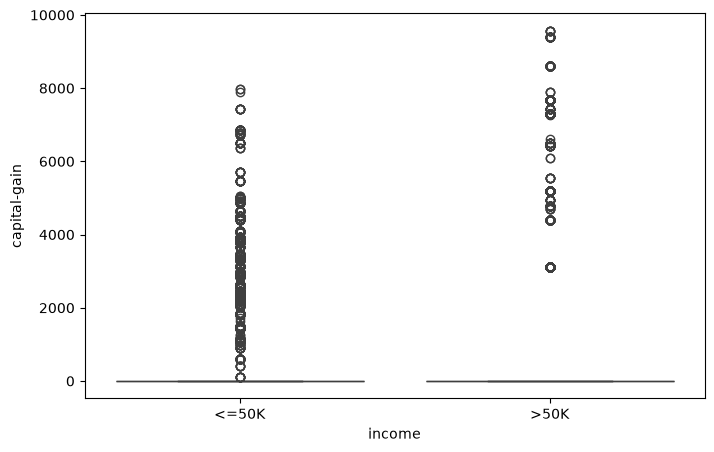

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[df['capital-gain'] < 10000],
    x='income',
    y='capital-gain'
)

plt.show()

Las ganancias de capital muestran una clara asociación con los ingresos elevados.

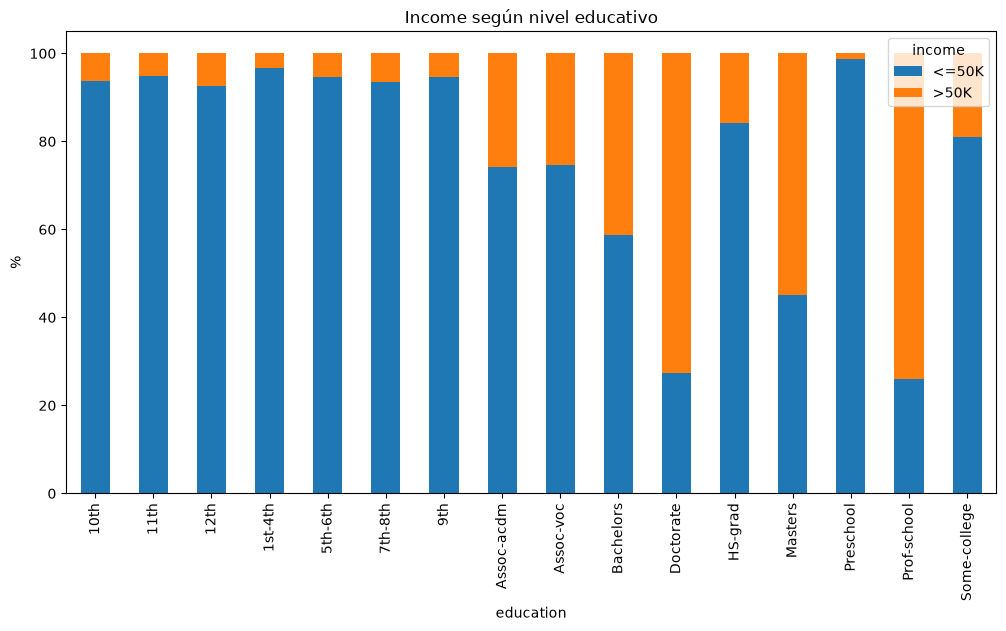

In [ ]:
tabla_edu.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Income según nivel educativo')
plt.ylabel('%')
plt.show()

Se aprecia una relación positiva entre el nivel educativo y la probabilidad de percibir ingresos superiores sobre todo en profschool y doctorado 

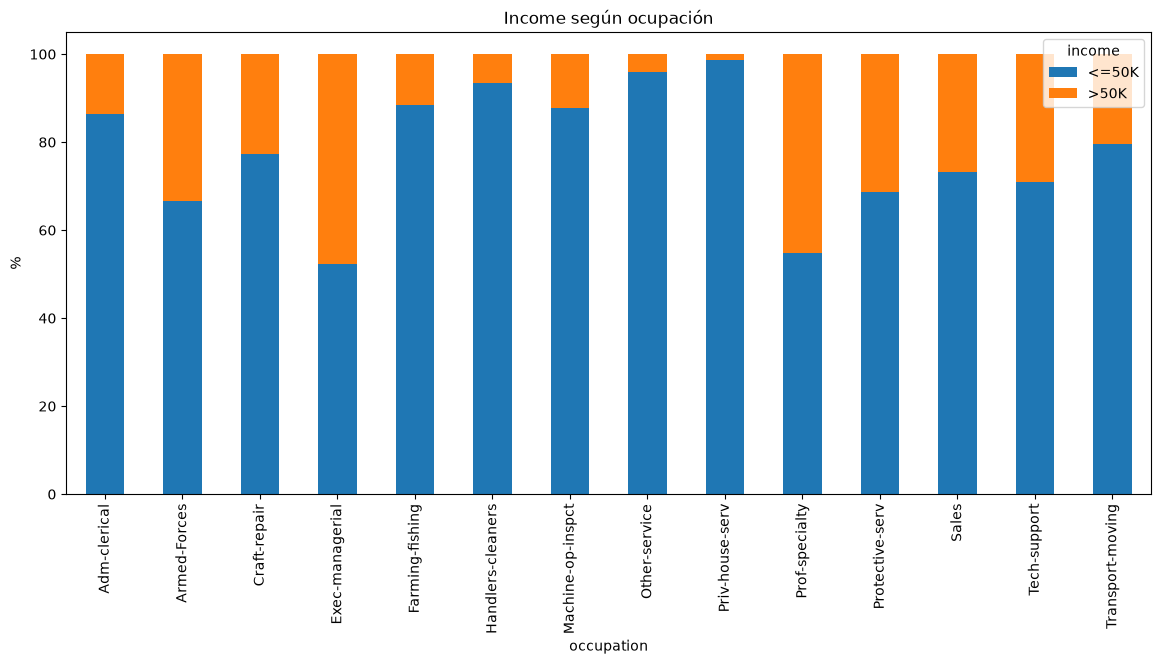

In [ ]:
tabla_occ = pd.crosstab(
    df['occupation'],
    df['income'],
    normalize='index'
) * 100

tabla_occ.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title('Income según ocupación')
plt.ylabel('%')
plt.show()

los ejecutivos y los prof-specialty se ve que son los mas probables a ganar los 50mil euros 

Ahora pasamos a hacer el analisis multivariable 

In [ ]:
numericas = [
    'age',
    'educational-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

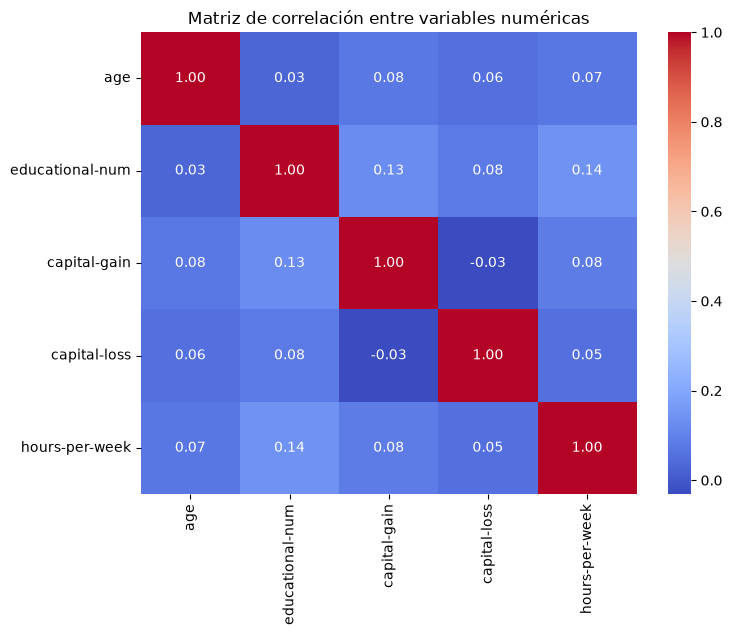

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numericas].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación entre variables numéricas')
plt.show()

En la matriz de correlación no se observan relaciones demasiado altas entre las variables numéricas por lo que entendemos que no hay un problema de multicolinealidad y que cada variable aporta informacion diferente al modelo 


In [ ]:
muestra = df.sample(2000, random_state=42)

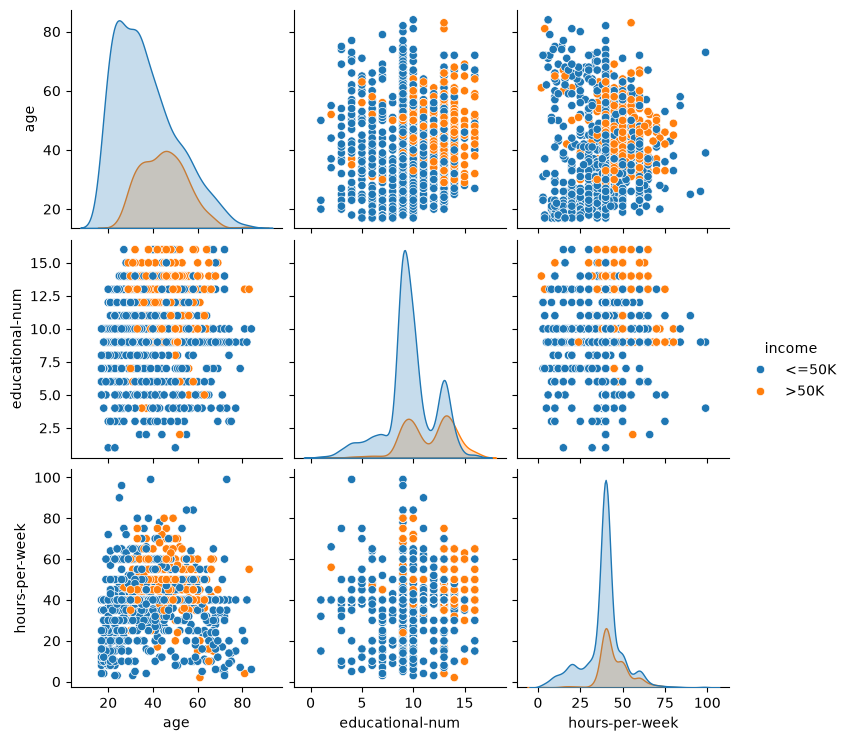

In [ ]:
sns.pairplot(
    muestra,
    vars=['age', 'educational-num', 'hours-per-week'],
    hue='income'
)

plt.show()

En el pairplot se puede ver que las clases se mezclan bastante,
por lo que no hay una separación perfecta entre ingresos altos y bajos.

In [ ]:
from scipy.stats import f_oneway

In [ ]:
variables_numericas = [
    'age',
    'educational-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss'
]

In [ ]:
#hecho con ia 
resultados_anova = []

for variable in variables_numericas:
    
    grupo_menor = df[df['income'] == '<=50K'][variable]
    grupo_mayor = df[df['income'] == '>50K'][variable]
    
    stat, p_value = f_oneway(grupo_menor, grupo_mayor)
    
    resultados_anova.append([variable, stat, p_value])

anova_df = pd.DataFrame(
    resultados_anova,
    columns=['Variable', 'F-statistic', 'p-value']
)

anova_df

,Variable,F-statistic,p-value
0,age,2737.207112,0.000000e+00
1,educational-num,6075.369398,0.000000e+00
2,hours-per-week,2670.362124,0.000000e+00
3,capital-gain,2556.179071,0.000000e+00
4,capital-loss,1087.027570,8.543599e-236


Los resultados muestran que todas las variables numéricas analizadas presentan valores p inferiores a 0.05, por lo que existen diferencias estadísticamente significativas entre los grupos de ingresos.
La variable que presenta una mayor diferencia entre ambos grupos es educational-num, seguida de age, hours-per-week y capital-gain. esto nos indica que las variables son facotes que si influyen de manera importante en el nivel de ingresos 



In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
variables_categoricas = [
    'workclass',
    'education',
    'occupation',
    'marital-status',
    'relationship',
    'race',
    'gender',
    'native-country'
]

In [ ]:
#hecho con ia
resultados_chi = []

for variable in variables_categoricas:
    
    tabla = pd.crosstab(df[variable], df['income'])
    
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    resultados_chi.append([variable, chi2, p_value])

chi_df = pd.DataFrame(
    resultados_chi,
    columns=['Variable', 'Chi2', 'p-value']
)

chi_df.sort_values('Chi2', ascending=False)

,Variable,Chi2,p-value
4,relationship,10088.722490,0.000000e+00
3,marital-status,9816.015037,0.000000e+00
1,education,6537.972961,0.000000e+00
2,occupation,5502.144900,0.000000e+00
6,gender,2248.847679,0.000000e+00
0,workclass,1238.990039,2.612180e-263
5,race,487.026287,4.284378e-104
7,native-country,451.176014,4.946550e-71


Las variables con mayor valor Chi2 son relationship, marital-status, education y occupation, por lo que parecen ser las categóricas más relacionadas con el nivel de ingresos.
En cambio, race y native-country también tienen relación con la variable objetivo, pero su asociación es menor en comparación con el resto de las variables 

,Variable,Cramers_V
4,relationship,0.454487
3,marital-status,0.448302
1,education,0.365868
2,occupation,0.345725
6,gender,0.214577
0,workclass,0.164041
5,race,0.099857
7,native-country,0.096966


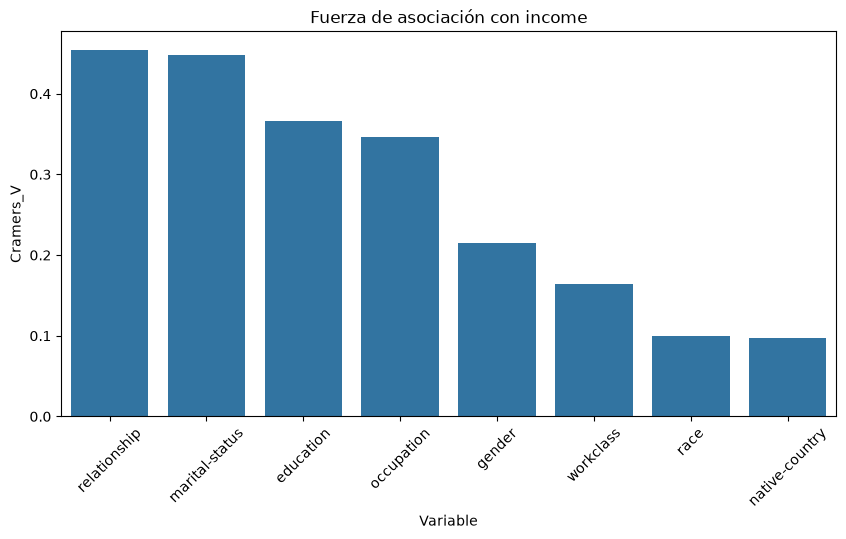

In [ ]:
#hecho con ia 


from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variables categóricas que existen en el dataframe
variables_categoricas = [
    col for col in [
        'workclass',
        'education',
        'occupation',
        'marital-status',
        'relationship',
        'race',
        'gender',
        'native-country'
    ] if col in df.columns
]

resultados_cramer = []

for variable in variables_categoricas:
    
    tabla = pd.crosstab(df[variable], df['income'])
    
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    n = tabla.sum().sum()
    r, k = tabla.shape
    
    cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
    
    resultados_cramer.append([variable, cramers_v])

cramer_df = pd.DataFrame(
    resultados_cramer,
    columns=['Variable', 'Cramers_V']
).sort_values('Cramers_V', ascending=False)

display(cramer_df)

plt.figure(figsize=(10,5))

sns.barplot(
    data=cramer_df,
    x='Variable',
    y='Cramers_V'
)

plt.title("Fuerza de asociación con income")
plt.xticks(rotation=45)
plt.show()


Para complementar la prueba Chi-cuadrado se ha calculado el coeficiente Cramer's V, que permite medir la fuerza de la relación entre las variables categóricas y la variable objetivo.

Se observa que las variables más relacionadas con el nivel de ingresos son relationship, marital-status, education y occupation, por lo que parecen ser las más importantes dentro de las variables categóricas.

ya habiendo hecho el EDA pasamos a la parte del preprocesing donde transformaremos las variables, haremos los encodings y limpiaremos los codigos para poder pasar a la fase de modelado 